<a href="https://colab.research.google.com/github/amelyssaeu-ab/bio-dkm/blob/main/tarefa04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarefa 04: Quartis, Mediana e Boxplot
### Análise do número de interações entre plantas e beija-flores em áreas verdes urbanas

######**Drielly Mathias Albertti - nº 16831084**
######**Kawana Ganeo de Carvalho - nº 14669691**
######**Melyssa Ponce Lopes - nº 16831017**



## 1. Contexto dos dados e da variável selecionada

A planilha original (`tarefa04.xlsx`) traz uma **matriz de interação planta–beija-flor**: para cada uma das **21 espécies de plantas** visitadas, é registrado o número de interações (visitas) observadas com cada uma das **6 espécies de beija-flor** do estudo (Sánchez Sánchez & Lara, 2024).

A partir dessa matriz, organizamos a variável quantitativa usada nesta análise: o **número total de interações registradas por espécie de planta**, obtido somando, para cada planta, as interações com todas as espécies de beija-flor. Essa contagem está na aba `Total_Interacoes_por_Planta` do arquivo `tarefa4.xlsx` (a matriz completa, com o total por planta, também está disponível na aba `Dados`).

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carregar as duas abas do arquivo organizado
df_dados = pd.read_excel("tarefa4.xlsx", sheet_name="Dados")
df_total = pd.read_excel("tarefa4.xlsx", sheet_name="Total_Interacoes_por_Planta")

# Ambas as abas têm linhas de rodapé com a fonte dos dados;
# mantemos apenas as linhas em que o total é numérico
df_dados = df_dados[pd.to_numeric(df_dados["Total de interações"], errors="coerce").notna()].copy()
df_dados["Total de interações"] = df_dados["Total de interações"].astype(int)

df_total = df_total[pd.to_numeric(df_total["Número total de interações"], errors="coerce").notna()].copy()
df_total["Número total de interações"] = df_total["Número total de interações"].astype(int)
df_total = df_total.sort_values("Número total de interações", ascending=False).reset_index(drop=True)

print("Matriz de interações planta–beija-flor (primeiras linhas):")
display(df_dados.head())

print("\nNúmero total de interações por espécie de planta:")
display(df_total)

Matriz de interações planta–beija-flor (primeiras linhas):


,Espécie de planta,Hylocharis chrysura,Chlorostilbon lucidus,Anthracothorax nigricollis,Florisuga fusca,Thalurania glaucopis,Chrysuronia versicolor,Total de interações
0,Megaskepasma erythrochlamys,109.0,93.0,13.0,3.0,0.0,0.0,218
1,Pachystachys lutea,5.0,9.0,0.0,0.0,0.0,0.0,14
2,Justicia floribunda,10.0,0.0,0.0,0.0,0.0,0.0,10
3,Justicia carnea,8.0,24.0,0.0,0.0,0.0,0.0,32
4,Aloe arborescens,65.0,0.0,0.0,0.0,0.0,0.0,65



Número total de interações por espécie de planta:


,Espécie de planta,Número total de interações
0,Inga sessilis,732
1,Bauhinia variegata,395
2,Russelia equisetiformis,220
3,Megaskepasma erythrochlamys,218
4,Hibiscus rosa-sinensis,77
5,Aloe arborescens,65
6,Ceiba speciosa,45
7,Justicia carnea,32
8,Callistemon viminalis,26
9,Salvia splendens,23


## 2. Fundamentação teórica — quartis, mediana e boxplot

Segundo Bussab e Morettin (2017), as **medidas separatrizes** dividem um conjunto de dados ordenado em partes com quantidades iguais de observações. A mais conhecida é a **mediana** ($Q_2$), valor que separa a série ordenada em duas metades: 50% das observações ficam abaixo dela e 50% acima.

Os **quartis** generalizam essa ideia, dividindo os dados ordenados em quatro partes iguais:

- **Primeiro quartil ($Q_1$):** valor abaixo do qual ficam aproximadamente 25% das observações;
- **Segundo quartil ($Q_2$):** a própria mediana (50% das observações abaixo);
- **Terceiro quartil ($Q_3$):** valor abaixo do qual ficam aproximadamente 75% das observações.

A diferença $Q_3 - Q_1$ é chamada de **amplitude interquartílica (IQR)** e mede a dispersão da metade central dos dados, sendo pouco sensível a valores extremos.

O **boxplot**, segundo os mesmos autores, é uma representação gráfica que resume a posição central, a dispersão e a presença de possíveis valores atípicos de um conjunto de dados quantitativos, a partir de $Q_1$, $Q_2$, $Q_3$ e dos limites construídos com o IQR.

In [ ]:
serie = df_total["Número total de interações"]

q1 = serie.quantile(0.25)
q2 = serie.quantile(0.50)  # mediana
q3 = serie.quantile(0.75)
iqr = q3 - q1

print(f"Q1 (1º quartil): {q1}")
print(f"Q2 (mediana):    {q2}")
print(f"Q3 (3º quartil): {q3}")
print(f"IQR (Q3 - Q1):   {iqr}")
print()
print(serie.describe())

Q1 (1º quartil): 10.0
Q2 (mediana):    19.0
Q3 (3º quartil): 65.0
IQR (Q3 - Q1):   55.0

count     21.000000
mean      92.476190
std      176.628599
min        2.000000
25%       10.000000
50%       19.000000
75%       65.000000
max      732.000000
Name: Número total de interações, dtype: float64


### Interpretação dos quartis

Com $Q_1 = 10$, $Q_2 = 19$ e $Q_3 = 65$ interações, a interpretação é a seguinte:

- **25% das 21 espécies de plantas** registraram **até 10 interações** no total com os beija-flores;
- **metade das plantas (mediana)** teve **19 interações ou menos**, e a outra metade teve 19 ou mais;
- **75% das plantas** ficaram com **até 65 interações**, restando apenas 25% delas acima desse valor.

O IQR de 55 interações mostra que a metade central dos dados já tem uma dispersão considerável — e essa dispersão fica ainda mais evidente quando comparamos com o valor máximo da amostra (732 interações, de *Inga sessilis*), muito acima de $Q_3$. Isso sugere, desde já, uma distribuição assimétrica à direita, com poucas plantas concentrando um número muito grande de interações.

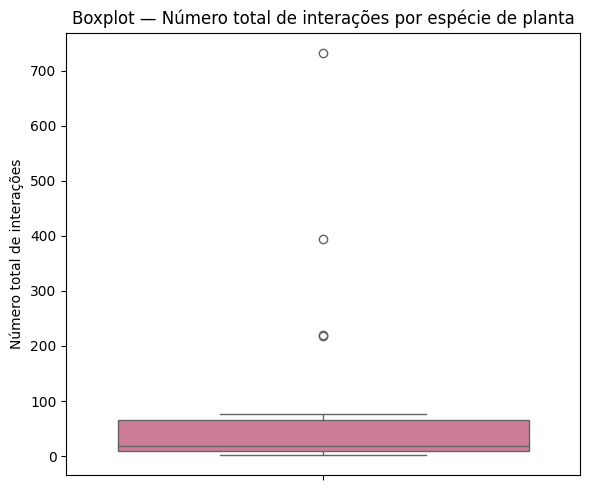

In [ ]:
plt.figure(figsize=(6, 5))
sns.boxplot(y=serie, color="palevioletred")
plt.title("Boxplot — Número total de interações por espécie de planta")
plt.ylabel("Número total de interações")
plt.tight_layout()
plt.show()

### Interpretação do boxplot

O boxplot confirma a assimetria observada nos quartis: a caixa (entre $Q_1 = 10$ e $Q_3 = 65$) é relativamente compacta perto da base do gráfico, com a mediana ($Q_2 = 19$) também próxima da parte inferior da caixa — sinal de que a maioria das plantas tem um número de interações relativamente baixo.

Acima do bigode superior aparecem quatro pontos isolados, correspondentes a **Megaskepasma erythrochlamys** (218), **Russelia equisetiformis** (220), **Bauhinia variegata** (395) e, destacando-se ainda mais, **Inga sessilis** (732). Essas espécies funcionam como verdadeiros "polos" de atração de beija-flores na comunidade estudada, concentrando um número de interações muito acima do restante das plantas — um padrão coerente com o que a literatura de redes de interação planta-polinizador chama de espécies "hub" (super-generalistas).

## 3. Como determinar se há observações atípicas em uma base de dados?

De acordo com Bussab e Morettin (2017), o critério mais usual para identificar **valores atípicos (outliers)** a partir do boxplot é a **regra do IQR (amplitude interquartílica)**. Definem-se dois limites, chamados *cercas* (do inglês *fences*):

$$\text{Limite inferior} = Q_1 - 1{,}5 \times IQR$$
$$\text{Limite superior} = Q_3 + 1{,}5 \times IQR$$

Toda observação **menor que o limite inferior ou maior que o limite superior** é classificada como atípica e, no boxplot, é representada individualmente como um ponto fora dos "bigodes" (*whiskers*) do gráfico, que se estendem apenas até o menor e o maior valor observado que ainda estejam dentro desses limites.

A lógica por trás da regra é usar a dispersão da metade central dos dados (o IQR, que é resistente a valores extremos) como referência de "variação normal": qualquer ponto muito mais distante do centro do que essa variação típica é sinalizado como possivelmente atípico, merecendo investigação — pode refletir um fenômeno real e relevante (como neste caso) ou um erro de medição/digitação, e cabe à análise contextual decidir qual é o caso.

In [ ]:
lim_inf = q1 - 1.5 * iqr
lim_sup = q3 + 1.5 * iqr
print(f"Limite inferior: {lim_inf}")
print(f"Limite superior: {lim_sup}")

outliers = df_total[(serie < lim_inf) | (serie > lim_sup)]
print("\nEspécies de plantas classificadas como atípicas pela regra do IQR:")
display(outliers)

Limite inferior: -72.5
Limite superior: 147.5

Espécies de plantas classificadas como atípicas pela regra do IQR:


,Espécie de planta,Número total de interações
0,Inga sessilis,732
1,Bauhinia variegata,395
2,Russelia equisetiformis,220
3,Megaskepasma erythrochlamys,218


### Aplicação aos dados

Como $Q_1 = 10$ não pode ser negativo, o limite inferior ($10 - 1{,}5 \times 55 = -72{,}5$) não exclui nenhuma planta por baixo — o que faz sentido, já que o número de interações não pode ser negativo. Já o limite superior ($65 + 1{,}5 \times 55 = 147{,}5$) é ultrapassado por quatro espécies: **Megaskepasma erythrochlamys**, **Russelia equisetiformis**, **Bauhinia variegata** e **Inga sessilis**, exatamente as mesmas apontadas visualmente no boxplot.

Do ponto de vista ecológico, esse resultado não indica erro nos dados, e sim uma característica real e bem documentada de redes planta-polinizador: poucas espécies concentram a maior parte das interações, enquanto a maioria contribui com relativamente poucas visitas. Ainda assim, o critério estatístico é o que nos permite apontar, de forma objetiva e reprodutível, quais espécies se destacam o suficiente para merecer atenção especial na análise.

## 4. Referências

BUSSAB, Wilton de O.; MORETTIN, Pedro A. **Estatística Básica**. 9. ed. São Paulo: Saraiva, 2017. Disponível em: <https://www.professores.uff.br/jutriavaldes/wp-content/uploads/sites/196/2019/08/Book_EstatBas-Morettin-Bussab.pdf>. Acesso em: 18 ago. 2026.

SÁNCHEZ SÁNCHEZ, Monserrat; LARA, Carlos. Exotic and native plants play equally important roles in supporting and structuring plant-hummingbird networks within urban green spaces. **PeerJ**, v. 12, e16996, 2024. Disponível em: <https://pmc.ncbi.nlm.nih.gov/articles/PMC11621834/#sec10>. Acesso em: 18 ago. 2026.